# Landing Analysis

In [1]:
import os
import tomllib
import json
from datetime import date
from pathlib import Path
from importlib import  reload

# Add the parent directory to the system path
import sys
sys.path.append(os.path.abspath('..'))

from src.data_loaders import read_telemetry_csv, load_runway_db
from src.parsers import extract_date_name_tacview
from src.transformer_plotter import (transform_telemetry, 
                                    touchdown_discovery,
                                    style_result_table,
                                    plot_landing_profile,
                                    touchdown_plotter)

# Load the configuration file
notebook_dir = Path.cwd()
config_path = notebook_dir.parent / "config.toml"
PROJECT_ROOT = config_path.parent.parent
with config_path.open('rb') as f:
    config = tomllib.load(f)

REF_PATH             = PROJECT_ROOT / Path(config["db_path"]["REF_PATH"])
RESULTS_DIR         = PROJECT_ROOT / Path(config["output"]["RESULTS_DIR"])

# Set the CSV path
CSV_PATH            = PROJECT_ROOT / Path(config['input']['CSV_PATH'])
print(f"CSV_PATH: {CSV_PATH}")

CSV_PATH: c:\Users\Fardad\Desktop\Landing Project\Approach-Landing-Analyzer\data\raw\Reduced_Tacview-20250831-211257-DCS-Client-IQT-1 Checkride 1.csv


In [2]:
# Make the output directory
record_date, mission_name = extract_date_name_tacview(CSV_PATH)
if record_date is None:
    record_date = date.today().strftime("%Y%m%d")

plots_output_path = RESULTS_DIR/f"[{record_date}] {mission_name}"
detailed_td_path = plots_output_path/"Detailed Touchdowns"

detailed_td_path.mkdir(parents=True, exist_ok=True)

print(f"record_date: {record_date}")

record_date: 20250831


## 1. Load DB once

In [3]:
# 1. Load DB
runway_db = load_runway_db(REF_PATH)

Runway DB loaded successfully.


## 2. Touchdown Discovery

In [4]:
# 2. Touchdown Discovery

# Read the telemetry data
df = read_telemetry_csv(CSV_PATH)
# clean and transform the data
df_sub = transform_telemetry(df)
# Discover the touch downs
df_result = touchdown_discovery(df_sub, runway_db)

All touchdown instances are discovered in df_result!


## 3. CSS Stylized Results Table

In [5]:
# 3. CSS Stylized Results Table
stylized_table = style_result_table(df_result, plots_output_path, record_date)
stylized_table

Exported styled HTML.
Exported table image.


Sortie,Touchdown Time,Aircraft,Pilot,CAS (kt),VS (fpm),Airport,Runway,Touchdown to Threshold (ft)
1,2020-05-31 21:31:12.297144,F-16C_50,< 404C > Phoenix,173,-501,PGSN,07,3198
2,2020-05-31 22:22:46.594193,F-16C_50,< 404C > Phoenix,172,-69,PGUA,06L,3391
1,2020-05-31 22:30:08.793771,F-16C_50,< 404 > D1CE,173,-198,PGUA,06L,1297
3,2020-05-31 22:41:09.093141,F-16C_50,< 404C > Phoenix,162,-190,PGUA,06L,463
3,2020-05-31 22:41:14.693136,F-16C_50,< 404C > Phoenix,157,-387,PGUA,06L,1949


## 4. Plot Approach Profiles

Here are all landing profiles:


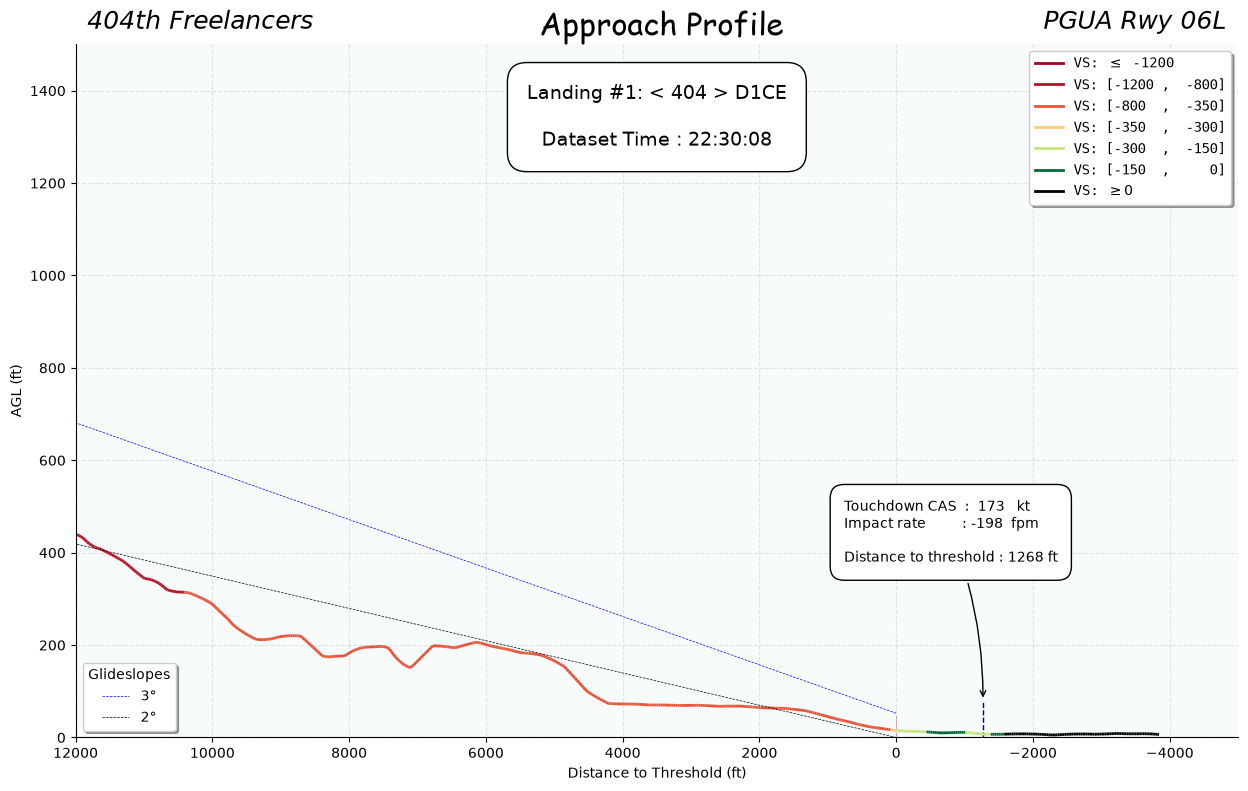

In [ ]:
# 3. Plot/Export Profiles
for pilot in df_result['Pilot'].sort_values().unique():
    for sortie_num in df_result[df_result['Pilot'] == pilot]['sortie_num'].unique():
        is_sortie = plot_landing_profile(df_sub, df_result, pilot, sortie_num, 
                                        plots_output_path, record_date, 
                                        close_fig = False)

print("Here are all landing profiles:")

## 5. Detailed Touchdowns (optional)

In [60]:
import src.transformer_plotter
reload(src.transformer_plotter)
from src.transformer_plotter import touchdown_plotter


c:\Users\Fardad\Desktop\Landing Project\Approach-Landing-Analyzer\backend\src\transformer_plotter.py:74: SyntaxWarning: invalid escape sequence '\l'
  labels = [f'$\leq$ {thresholds[1]}']
c:\Users\Fardad\Desktop\Landing Project\Approach-Landing-Analyzer\backend\src\transformer_plotter.py:79: SyntaxWarning: invalid escape sequence '\g'
  labels.append(  f'$\geq 0$'  )


Sortie #4 of < 404C > Phoenix Took less than 6 second!
All Touchdowns Plotted!


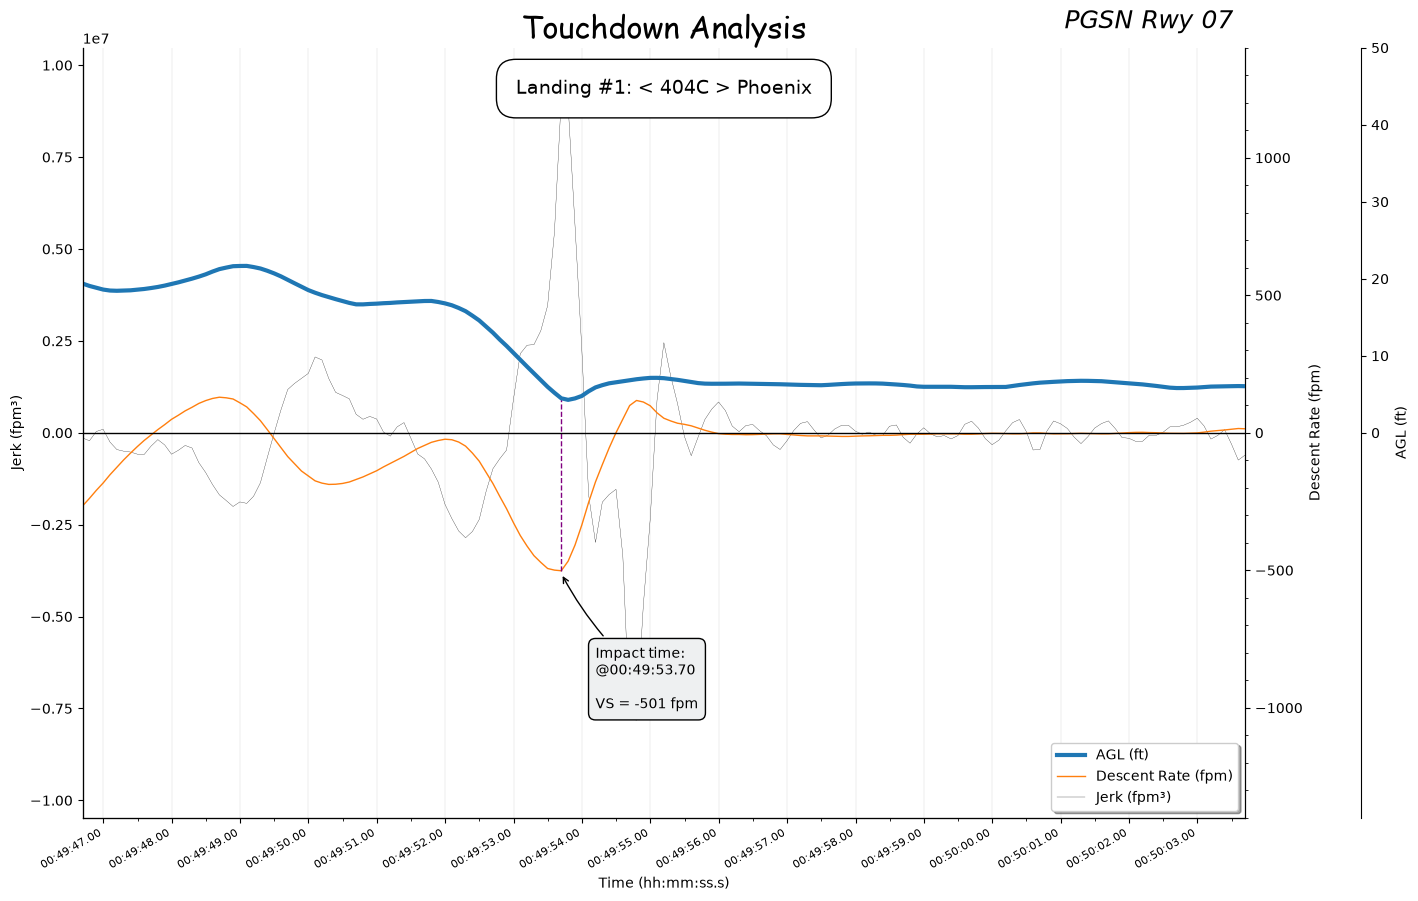

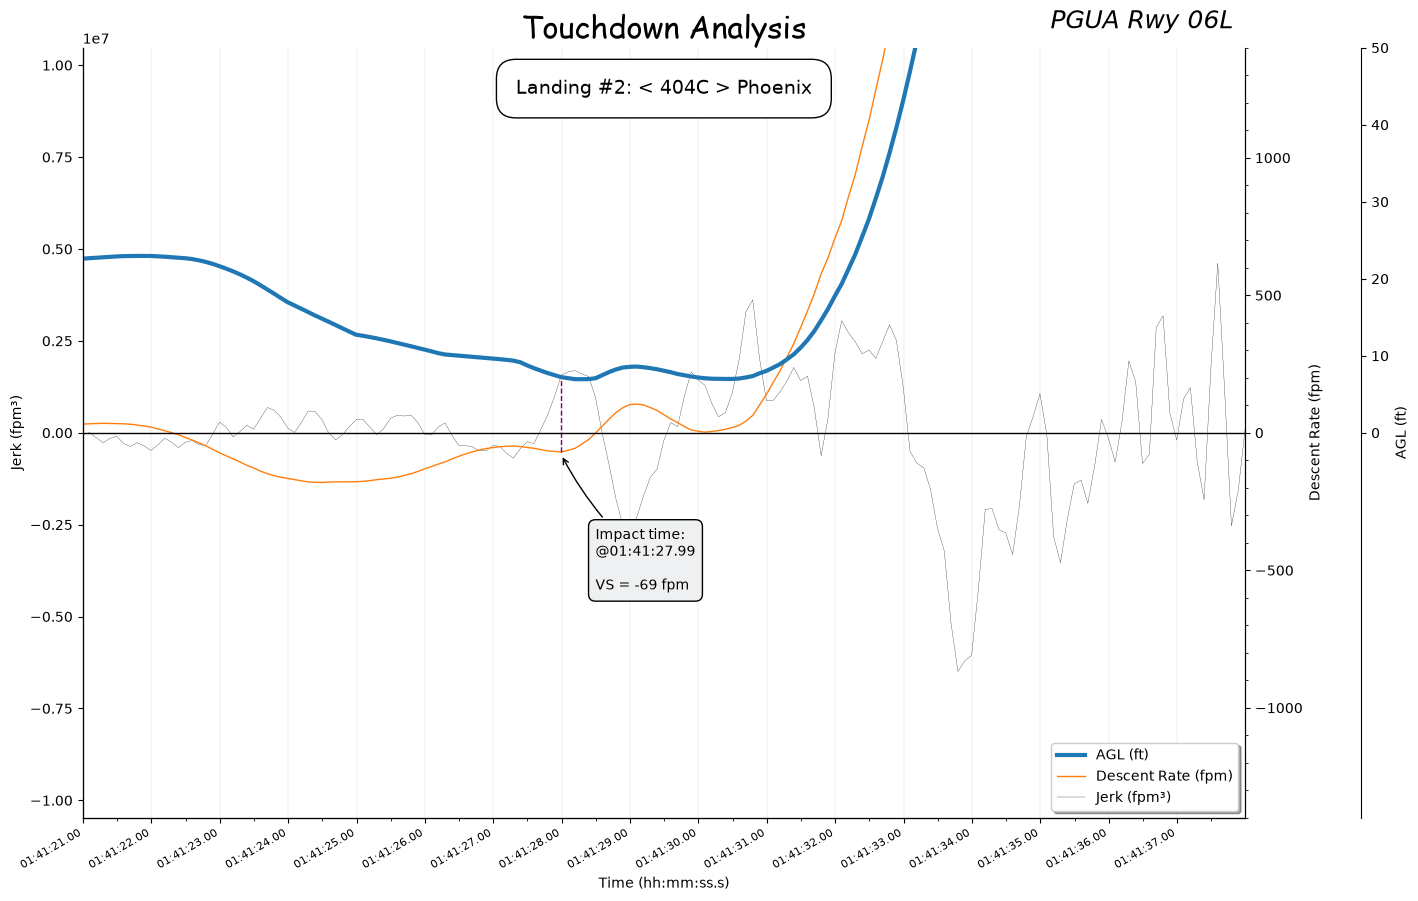

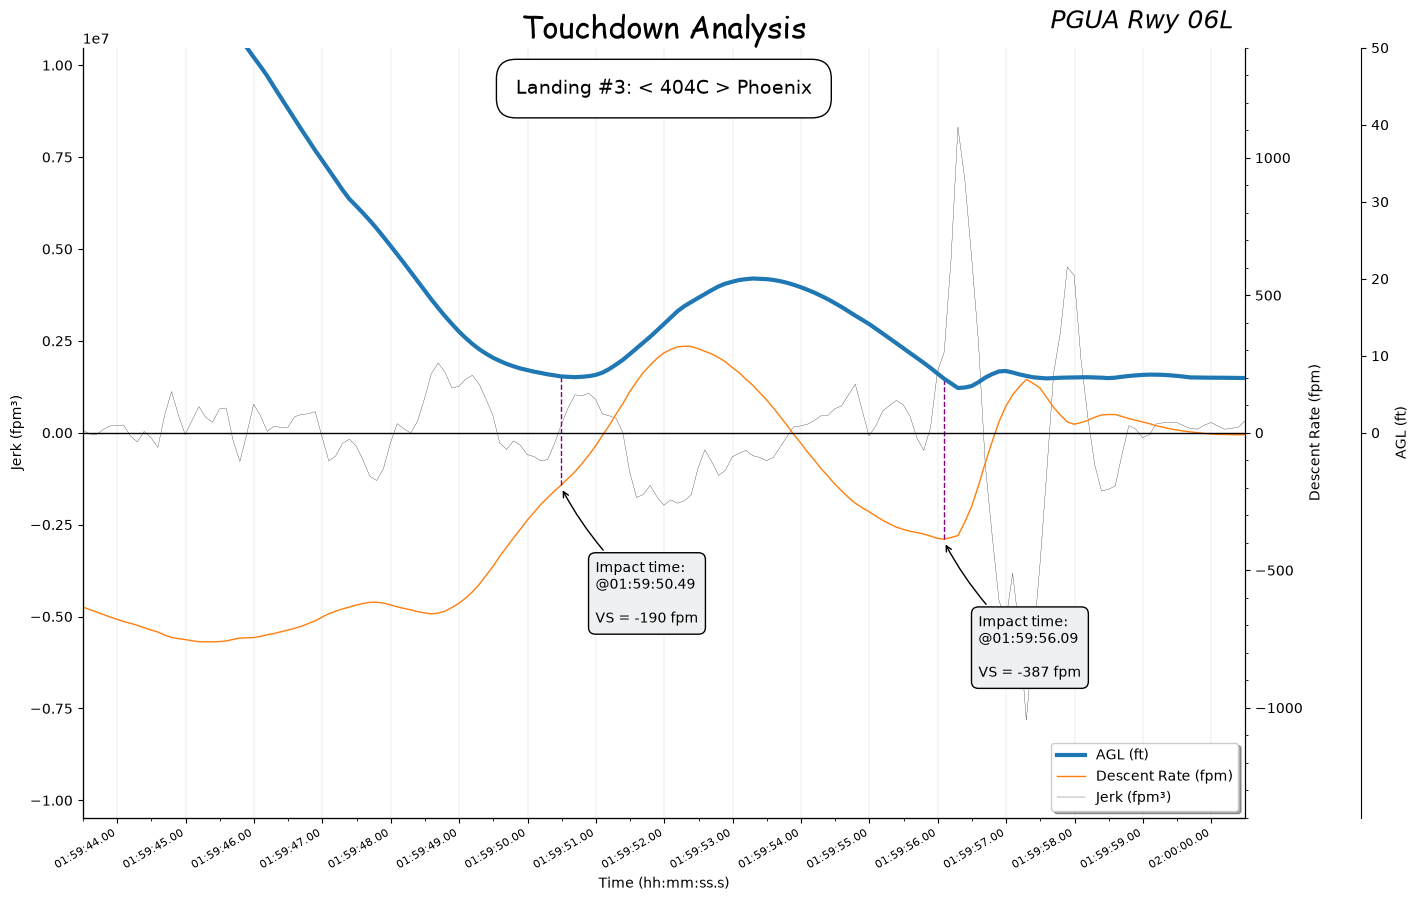

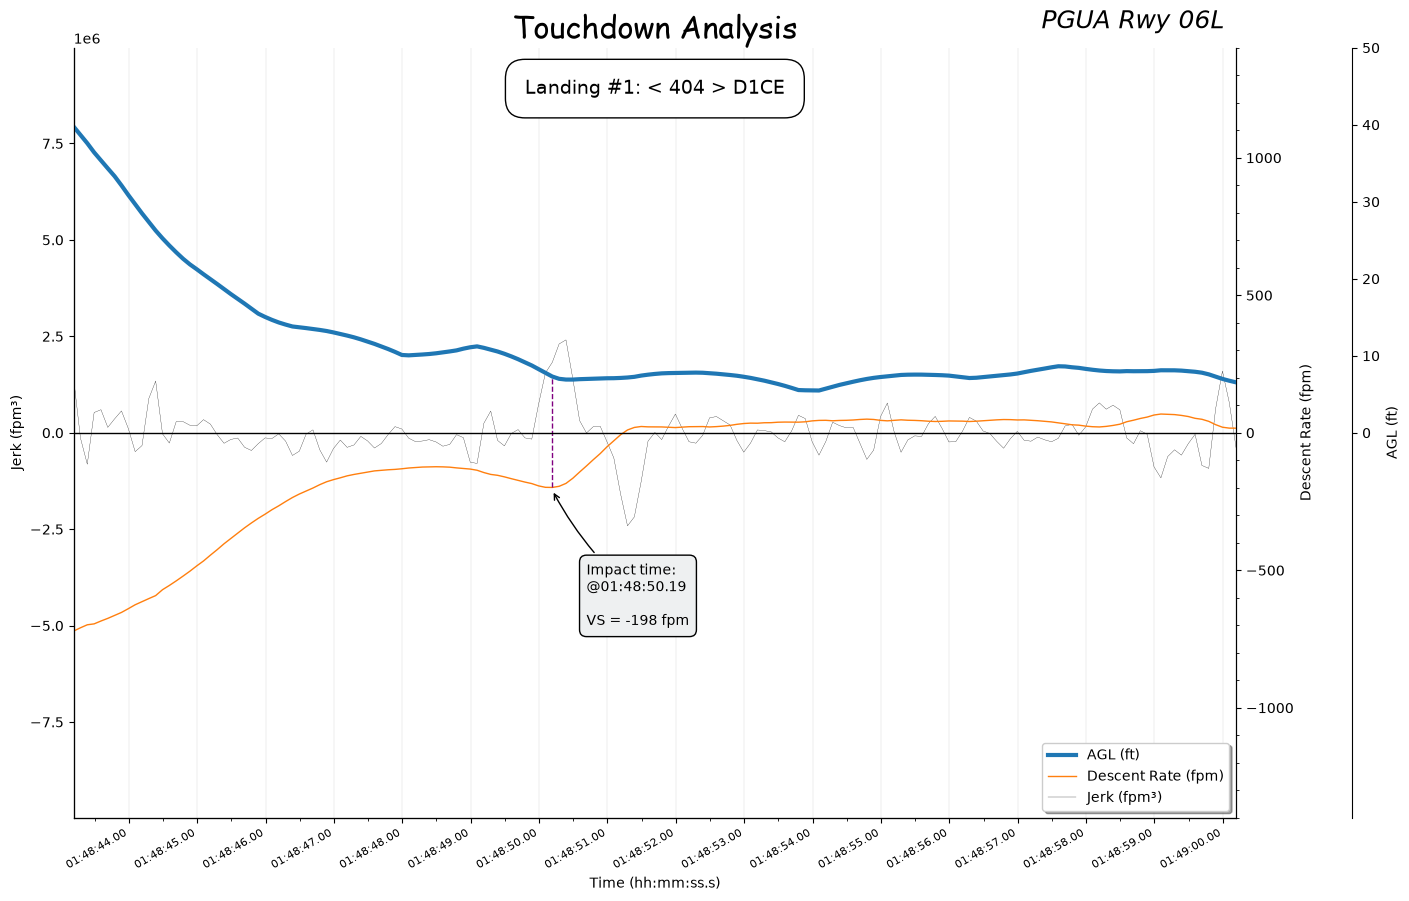

In [ ]:
# Plot/Export Touchdowns
for pilot in df_result['Pilot'].unique():
    for sortie_num in df_result[df_result['Pilot'] == pilot]['sortie_num'].unique():
        touchdown_plotter(df_sub, df_result, pilot, sortie_num, 
                        detailed_td_path, record_date, 
                        close_fig = False)

print("All Touchdowns Plots:")